# Molecular Dynamics of HDAC8

- **Author**: Yamila Timmer
- **Date**: 29-01-2026

## Imports & loading universe objects

In [3]:
# imports
import MDAnalysis as mda
from MDAnalysis.analysis import rms, distances
from MDAnalysis.analysis.dssp import DSSP, translate
import matplotlib.pyplot as plt
import numpy as np

In [93]:
# Create universe objects
# ------ General objects, with PDB + complete, 250ns trajectory
WT_0_complete = mda.Universe("../variants/WT/WT-0-ion.pdb", "../variants/WT/WT-0-ion.xtc")
WT_1_complete = mda.Universe("../variants/WT/WT-1-ion.pdb", "../variants/WT/WT-1-ion.xtc")
WT_2_complete = mda.Universe("../variants/WT/WT-2-ion.pdb", "../variants/WT/WT-2-ion.xtc")

WT_0 = mda.Universe("../variants/WT/WT-0-last-50ns-avg.pdb", "../variants/WT/WT-0-last-50ns.xtc")
WT_1 = mda.Universe("../variants/WT/WT-1-last-50ns-avg.pdb", "../variants/WT/WT-1-last-50ns.xtc")
WT_2 = mda.Universe("../variants/WT/WT-2-last-50ns-avg.pdb", "../variants/WT/WT-2-last-50ns.xtc")

G320R_0 = mda.Universe("../variants/G320R/G320R-0-last-50ns-avg.pdb",
                       "../variants/G320R/G320R-0-last-50ns.xtc")
G320R_1 = mda.Universe("../variants/G320R/G320R-1-last-50ns-avg.pdb",
                       "../variants/G320R/G320R-1-last-50ns.xtc")
G320R_2 = mda.Universe("../variants/G320R/G320R-2-last-50ns-avg.pdb",
                       "../variants/G320R/G320R-2-last-50ns.xtc")

H180R_0 = mda.Universe("../variants/H180R/H180R-0-last-50ns-avg.pdb",
                       "../variants/H180R/H180R-0-last-50ns.xtc")
H180R_1 = mda.Universe("../variants/H180R/H180R-1-last-50ns-avg.pdb",
                       "../variants/H180R/H180R-1-last-50ns.xtc")
H180R_2 = mda.Universe("../variants/H180R/H180R-2-last-50ns-avg.pdb",
                       "../variants/H180R/H180R-2-last-50ns.xtc")

H334R_0 = mda.Universe("../variants/H334R/H334R-0-last-50ns-avg.pdb",
                       "../variants/H334R/H334R-0-last-50ns.xtc")
H334R_1 = mda.Universe("../variants/H334R/H334R-1-last-50ns-avg.pdb",
                       "../variants/H334R/H334R-1-last-50ns.xtc")
H334R_2 = mda.Universe("../variants/H334R/H334R-2-last-50ns-avg.pdb",
                       "../variants/H334R/H334R-2-last-50ns.xtc")

T311M_0 = mda.Universe("../variants/T311M/T311M-0-last-50ns-avg.pdb",
                       "../variants/T311M/T311M-0-last-50ns.xtc")
T311M_1 = mda.Universe("../variants/T311M/T311M-1-last-50ns-avg.pdb",
                       "../variants/T311M/T311M-1-last-50ns.xtc")
T311M_2 = mda.Universe("../variants/T311M/T311M-2-last-50ns-avg.pdb",
                       "../variants/T311M/T311M-2-last-50ns.xtc")

# ------ Cropped objects, with PDB containing an avg "snapshot" of final 50ns of trajectory
WT_avg = mda.Universe("../variants/WT/WT-2-last-50ns-avg.pdb")
G320R_avg = mda.Universe("../variants/G320R/G320R-1-last-50ns-avg.pdb")
H180R_avg = mda.Universe("../variants/H180R/H180R-2-last-50ns-avg.pdb")
H334R_avg = mda.Universe("../variants/H334R/H334R-1-last-50ns-avg.pdb")
T311M_avg = mda.Universe("../variants/T311M/T311M-1-last-50ns-avg.pdb")

# ----- Objects used for determining secondary structure -------
WT_0_secondary = mda.Universe("../variants/WT/WT-0-ion.tpr", "../variants/WT/WT-0-ion.xtc").select_atoms('resid 1-376')
WT_1_secondary = mda.Universe("../variants/WT/WT-1-ion.tpr", "../variants/WT/WT-1-ion.xtc").select_atoms('resid 1-376')
WT_2_secondary = mda.Universe("../variants/WT/WT-2-ion.tpr", "../variants/WT/WT-2-ion.xtc").select_atoms('resid 1-376')

G320R_secondary = mda.Universe("../variants/G320R/G320R-1-ion.tpr", "../variants/G320R/G320R-1-ion.xtc").select_atoms('resid 1-376')
H180R_secondary = mda.Universe("../variants/H180R/H180R-2-ion.tpr", "../variants/H180R/H180R-2-ion.xtc").select_atoms('resid 1-376')
H334R_secondary = mda.Universe("../variants/H334R/H334R-1-ion.tpr", "../variants/H334R/H334R-1-ion.xtc").select_atoms('resid 1-376')
T311M_secondary = mda.Universe("../variants/T311M/T311M-1-ion.tpr", "../variants/T311M/T311M-1-ion.xtc").select_atoms('resid 1-376')

## Research Question
In this notebook a molecular dynamics approach was used to get a better insight of functional and structural changes of HDAC8 caused by mutations. 4 mutations of HDAC8 were analysed, that are known to be associated with Cornelia de Lange Syndrome. I chose this subject, as I will be analyzing data regarding a protein complex, of which a subunit (SMC3) is deacetylated by HDAC8 under normal circumstances. The research question I hope to answer is what the effects of the selected mutations are on the structure and dynamics of HDAC8 and how this regards to a (partial) loss-of-function.

## Biological Background

Cornelia de Lange Syndrome (CdLS) is a rare, but impactful, genetic disorder, named after the Dutch paediatrician who first described it in 1933 (De Lange, 1933). The disorder affects multiple domains, including the physical, such as the development of facial structure and limbs, the cognitive, with the majority displaying an intellectual disability, and the behavioral, including self-injurious or repetitive behavior (Kline et al., 2018). CdLS is caused by defects in the cohesin protein complex or in supporting proteins, also known as cohesinopathies (Kline et al., 2018). To date, various mutations of HDAC8 have been found associated with CdLS. CdLS cases caused by HDAC8 mutations are all sheltered under the subtype CdLS5.

Post-translational modification of histones is a largely studied field contributing to a better understanding of transcriptional regulation. One such form of modification is acetylation, which involves the donation of an acetyl group (-COCH₃) from acetyl coenzyme A (Ac-CoA) to a specific site on a protein. There are two distinct forms, acetylation of the N-terminal and acetylation of the ε-amino group of lysine residues (Drazic et al., 2016). Whereas histone acetyltransferases can donate an acetyl group to a target site in a protein, histone deacetylases can remove these groups. Histone acetylation determines transcriptional activity; hyperacetylation is associated with increased activity, while hypoacetylation is associated with repression of activity (De Ruijter et al., 2003). (de)Acetylation can also take place in other protein structures. HDAC8 was found to deacetylate K105 and K106 of SMC3 (Deardorff et al., 2016). Together with other proteins (SMC1, RAD21, and STAG), SMC3 forms the ring-shaped cohesin complex. This complex plays a vital role in gene regulation; it also ensures sister chromatid cohesion during the cell cycle to prevent sister chromatids from separating before anaphase (Deardorff et al., 2012). Deacetylation of SMC3 during anaphase is essential, as only deacetylated SMC3 can be recycled to form new cohesin complexes. Conversely, SMC3 acetylation during S‑phase is required to establish cohesion and ensure proper cohesin function (Deardorff et al., 2012).

17 missense mutations in HDAC8 have been identified in children diagnosed with CdLS (Decroos et al., 2015), of those 4 are analysed in this notebook, H180R, T311M, H334R and G320R.

## Structure HDAC8

HDAC8 is a relatively small enzyme, consisting of 377 residues. It only contains one distinctive domain, which is the histone deacetylase at position 14-324 (colored yellow). The enzyme requires one zinc ion as it is zinc-dependent, the ion can be seen having a central position in the protein. All locations of mutations that will be analyzed are coloured red. Three of them are in the histone deacetylase region and one lies outside. Locations outside of the histone deacetylase domain are colored blue.


### Mutations

The table below contains all mutations that are analyzed in this notebook. All of these mutations are known to be associated with CdLS5, a subtype of CdLS that is caused by mutations in HDAC8. The table shows the change in residue and at what position it takes place. It also shows the percentage of catalytic activity compared to the wildtype and the distance between the mutation and the Zn ion.

The remaining catalytic activity in comparison to the WT, differs per variant. H180R seems to not have any remaining catalytic activity, the reason for this is likely because residue 180 plays an important role in catalytic activity (also see the information on the active site below). Having an important residue change can lead to complete dysregulation of the active site. The distance of the mutated residue to the Zn ion was calculated in the assumption that the closer the mutation is to the active site, the more likely it has an impact on catalytic activity. The distance calculation was done in [the distance analysis section](###distance-analysis). The mutation closest to the Zn ion, only has a distance of 5.8Å (the size of 1 to 2 residues). The hypothesis that a mutated residue with a close distance to Zn is likely to have an effect on catalytic activity seems to uphold here, as HDAC8 with a H180R mutation has 0% catalytic activity. The T311M mutation is around double as far away from Zn as H180R, still here too, the catalytic activity seems drastically effected, with 6% of activity remaining. G320R is more than double as far away from Zn as T311M, but actually has a worse catalytic outcome, of only 1.5/2% of activity remaining. 22.59Å is a distance of around 6-7 residues, so it is still decently close to the active site, however. H334R is the mutation with the most distance, with 30.7Å to the Zn ion. It is possible that the sheer distance between mutation and active site could have made the mutation not as impactful on catalytic activity.

| Mutation | Position | Cat. Activity               | Dist to Zn  |
| -------- | -------- |-----------------------------|-------------|
| H > R    | 180      | 0% (Decroos et al., 2015)   | 5.8Å        |
| T > M    | 311      | 6% (Decroos et al., 2014)   | 10.5Å       |
| G > R    | 320      | 1.5-2% (Osko et al., 2020)  | 22.59Å      |
| H > R    | 334      | 91% (Decroos et al., 2014)  | 30.7Å       |

![](imgs/HDAC8-structure.gif)

### Active site

The active site of HDAC8 has a narrow tunnel shape, leading to the catalytic machinery. By observing these two structures, vital components of the active site can be identified. F152, F208, H180, G151, M274, and Y306 make up the structure of the tunnel (Somoza et al., 2004). Central to the active site lies a zinc ion, bound to carboxylate oxygens of D178 and D267 (Somoza et al., 2004). H180, D178 and D267 play a significant role in coordinating the Zn$^{2+}$ ion (Vannini et al., 2004).

![](imgs/catalytic_site_HDAC8.png)

The tunnel shape can clearly be observed when displaying the protein with `show surface, all`.

![](imgs/HDAC8_tunnel.png)

Components vital to the catalytic activity of HDAC8 are situated close to the central Zn${2+}$. His142, which is coordinated by Asp176, and His143, which is coordinated by Asp 183 also seem to play an important role. Finnin et al. (1999) proposed that the His142-Asp176 dyad abstracts a proton from water, thereby facilitating the nucleophilic attack that leads to the deacetylation of the lysine residue on the protein. The proposed role of His143-Asp183 is to donate a proton to the amine during the breakdown of the tetrahedral structure that exists during nucleophilic attack. The image below displays the proposed catalytic activity of HDAC8 (Decroos et al.,2015).

![](imgs/HDAC8_reaction.jpeg)


Some of the MD simulations seem to have timed out before reaching 250ns (possibly due to SLURM time limit). GROMACS makes a checkpoint every 15 minutes and simulations can be resumed from the last checkpoint using

```
gmx mdrun -v -deffnm WT-1-MD -cpi WT-1-MD.cpt
```

## Comparing alphafold variants (and maybe known PDB's)

Using AlphaFold, molecular structure was predicted for 5 different variants of SMC3. Including the wildtype with no
mutations and 4 known mutations that are connected to Cornelia de Lange syndrome. For each variant, 3 predicted
structures are compared, to compare and see if AlphaFold predictions for molecular structure of (mutated) SMC3 are
consistent.



### G320R
Loading all AlphaFold predictions and aligning them to see if AlphaFold predictions are consistent:
```
load G320R-0.pdb
load G320R-1.pdb
load G320R-2.pdb

alignto G320R-0
```
Below the result can be seen, the different predictions are clearly very closely related, with only minor differences
 in structure. The zinc ions seems to be completely overlapping for all three predictions. In the image, prediction 1
  is green,
 prediction 2 is
 blue and
 prediction 3 is pink.
The RMSD of G320R-0/G320R-1 = 0.472 and the RMSD of G320R-0/G320R-2 = 0.392

![](imgs/G320R-align.png)


## Run settings for simulation

As the AlphaFold predictions seem to be consistent, further analyzing can be done by simulating molecular dynamics. This is done by computing 250ns of protein movement using GROMACS (Bekker et al., 1993). This software simulates protein movement in a simulated repetitive space surrounding the protein, filled with water. Various forcefields can be used to calculate molecular dynamics, in this notebook CHARMM (Brooks et al., 2009) was chosen, as it is more suited for calculations involving ions, as opposed to the AMBER forcefields (Case et al., 2025), where it is necessary to immobilize the ion.

[gromit](https://github.com/marrink-lab/gromit), a wrapper for GROMACS was used. The wrapper includes a bash script that will fully go through all the steps of GROMACS, which makes it a lot easier to generate MD output. It was ran with the following command:

`gromit.sh -f $base.pdb -ff $FF -equil 0.01 -pre 0.01 -time 250 -d 2 \
     --mdp-nstxout=0 --mdp-nstpcouple=100 --mdp-nsttcouple=100 --mdp-nstenergy=100 --mdp-constraints=h-bonds --mdp-nstlist=50 -stop TPR`

- `-f`: input coordinate file (PDB)
- `-ff`: what forcefield to use
- `-equil`: equilibration run time (ns)
- `-pre`: preproduction run time (ns)
- `-time`: production run time (ns)
- `-d`: distance between images over PBC
- `--mdp-nstxout`: (0) [steps] number of steps that elapse between writing coordinates to the output trajectory file (trr), the first and last coordinates are always written unless 0, which means coordinates are not written into the trajectory file.
- `--mdp-nstpcouple`:(-1) The interval between steps that couple the pressure. The default value of -1 sets nstpcouple equal to 100, or fewer steps if required for accurate integration (5 steps per tau for first order coupling, 20 steps per tau for second order coupling). Note that the default value is large in order to reduce the overhead of the additional computation and communication required for obtaining the virial and kinetic energy. For velocity Verlet integrators nsttcouple is set to 1.
- `--mdp-nsttcouple`: (-1) The interval between steps that couple the temperature. The default value of -1 sets nsttcouple equal to 100, or fewer steps if required for accurate integration (5 steps per tau for first order coupling, 20 steps per tau for second order coupling). Note that the default value is large in order to reduce the overhead of the additional computation and communication required for obtaining the kinetic energy. For velocity Verlet integrators nsttcouple is set to 1.
- `--mdp-nstenergy`: (1000) [steps] number of steps that elapse between writing energies to the energy file (edr), the first and last energies are always written, should be a multiple of nstcalcenergy. Note that the exact sums and fluctuations over all MD steps modulo nstcalcenergy are stored in the energy file, so gmx energy can report exact energy averages and fluctuations also when nstenergy > 1
- `--mdp-constraints`:Controls which bonds in the topology will be converted to rigid holonomic constraints. Note that typical rigid water models do not have bonds, but rather a specialized [settles] directive, so are not affected by this keyword.     Convert the bonds with H-atoms to constraints.

- `--mdp-nstlist`: Interval between steps that update the neighbor list. When dynamics and verlet-buffer-tolerance set, nstlist is actually a minimum value and gmx mdrun might increase it, unless it is set to 1. With parallel simulations and/or non-bonded force calculation on the GPU, a value of 20 or 40 often gives the best performance. With energy minimization this parameter is not used as the pair list is updated when at least one atom has moved by more than half the pair list buffer size.
- `-stop`: at what step to stop, in this case it is set to TPR, meaning a tpr will only be written and not ran

The following command was used to start the 250ns run:
`gmx mdrun -deffnm $base-MD -pin on -pinstride 0 -ntmpi 1 -npme 0 -nb gpu -ntomp 12 -gpu_id 0 -bonded gpu -update gpu`

- `-deffnm`: sets the default filename for all file options
- `-pin`: whether mdrun should try to set thread affinities
- `-pinstride`: pinning distance in logical cores for threads, use 0 to minimize the number of threads per physical core
- `-ntmpi`: number of thread-MPI threads to start
- `-npme`: number of separate ranks to be used for PME
- `-nb`: calculate non-bonded interactions on
- `-ntomp`: number of OpenMP threads per MPI rank to start
- `-gpu_id`: list of GPU device id-s to use, specifies the per-node PP rank to GPU mapping
- `-bonded`:
- `-update`:

More info on usage of GROMACS can be found [https://manual.gromacs.org/current/index.html](here)


In order to visualize the molecular movement of HDAC8 and its mutated forms, first all hydrogen molecules and ions must be removed, with the exception of the cofactor Zn${2+}$ ion. To do this, an index file needs to be created, for the second WT prediction this would be:

`gmx make_ndx -f WT-1.gro -o index.ndx`

This gives the following selection:

```
There are:   377    Protein residues
There are:     1        Ion residues
Analysing Protein...

  0 System              :  5806 atoms
  1 Protein             :  5805 atoms
  2 Protein-H           :  2936 atoms
  3 C-alpha             :   377 atoms
  4 Backbone            :  1131 atoms
  5 MainChain           :  1509 atoms
  6 MainChain+Cb        :  1853 atoms
  7 MainChain+H         :  1869 atoms
  8 SideChain           :  3936 atoms
  9 SideChain-H         :  1427 atoms
 10 Prot-Masses         :  5805 atoms
 11 non-Protein         :     1 atoms
 12 Ion                 :     1 atoms

 nr : group      '!': not  'name' nr name   'splitch' nr    Enter: list groups
 'a': atom       '&': and  'del' nr         'splitres' nr   'l': list residues
 't': atom type  '|': or   'keep' nr        'splitat' nr    'h': help
 'r': residue              'res' nr         'chain' char
 "name": group             'case': case sensitive           'q': save and quit
 'ri': residue index
```

Select 0 and an index file containing the main system (protein + ion) is created. Now when making a reduces trajectory file and pdb file this index can be used.


For each output folder of GROMACS the command below can be run, as only one MD.tpr and MD.xtc file exist per folder. This wil generate a trajectory file containing only the simulated movement of the atoms of the protein and the Zn2+ ion.

`gmx trjconv -s *MD.tpr -f *MD.xtc -pbc mol -o protein_ion.xtc -n index.ndx -center`

Select 0 for group selection and for centering selection.

```
Select group for output
Group     0 (         System) has  5806 elements
Group     1 (        Protein) has  5805 elements
Group     2 (      Protein-H) has  2936 elements
Group     3 (        C-alpha) has   377 elements
Group     4 (       Backbone) has  1131 elements
Group     5 (      MainChain) has  1509 elements
Group     6 (   MainChain+Cb) has  1853 elements
Group     7 (    MainChain+H) has  1869 elements
Group     8 (      SideChain) has  3936 elements
Group     9 (    SideChain-H) has  1427 elements
Group    10 (    Prot-Masses) has  5805 elements
Group    11 (    non-Protein) has     1 elements
Group    12 (            Ion) has     1 elements
Group    13 (    Protein_Ion) has  5806 elements
```

Besides an adjusted trajectory file, an adjusted pdb is also needed. This can be done by 'dumping' the first frame of the trajectory with:

`gmx trjconv -s *MD.tpr -f protein_ion.xtc -pbc mol -o protein-ion.pdb -dump 0 -n index.ndx -center`

Again select group 0 for both selections.


Now using the adjusted pdb in combination with the adjusted xtc (with non-jumping systems), the movement of protein can be simulated over time (250ns).

## Analysis of Variants

The simulation can now be viewed in PyMol. The protein needs to be fitted, as it moves too much to properly analyze it. Below it is fitted on all alpha carbons, except for those in loops (as they tend to move a lot).

```
load WT-ion.pdb, WT
load WT-ion.xtc, WT
intra_fit WT and name CA and not ss l
```


### Secondary Structures
Below the average secondary structures are determined, meaning the average form residues take over the entirety of the simulation. The results can be used to annotate our RMSF graphs.


In [61]:
# Average secondary structure
secondary_structures = {}

for variant in [WT_0_secondary, WT_1_secondary, WT_2_secondary]:
                #G320R_secondary, H180R_secondary,
                #H334R_secondary, T311M_secondary]:
    long_run = DSSP(variant).run()
    mean_secondary_structure = translate(long_run.results.dssp_ndarray.mean(axis=0))
    secondary_structures[variant] = ''.join(mean_secondary_structure)

KeyboardInterrupt: 

### Calculating RMSF

(do this with avg structure)

In [94]:
def calculate_RMSF(universe):

    c_alphas = universe.select_atoms('protein and name CA')
    R = rms.RMSF(c_alphas).run()

    return c_alphas, R

c_alphas_WT_0_complete, R_WT_0_complete = calculate_RMSF(WT_0_complete)
c_alphas_WT_1_complete, R_WT_1_complete = calculate_RMSF(WT_1_complete)
c_alphas_WT_2_complete, R_WT_2_complete = calculate_RMSF(WT_2_complete)

c_alphas_WT_0, R_WT_0 = calculate_RMSF(WT_0)
c_alphas_WT_1, R_WT_1 = calculate_RMSF(WT_1)
c_alphas_WT_2, R_WT_2 = calculate_RMSF(WT_2)

c_alphas_G320R_0, R_G320R_0 = calculate_RMSF(G320R_0)
c_alphas_G320R_1, R_G320R_1 = calculate_RMSF(G320R_1)
c_alphas_G320R_2, R_G320R_2 = calculate_RMSF(G320R_2)

c_alphas_H180R_0, R_H180R_0 = calculate_RMSF(H180R_0)
c_alphas_H180R_1, R_H180R_1 = calculate_RMSF(H180R_1)
c_alphas_H180R_2, R_H180R_2 = calculate_RMSF(H180R_2)


c_alphas_H334R_0, R_H334R_0 = calculate_RMSF(H334R_0)
c_alphas_H334R_1, R_H334R_1 = calculate_RMSF(H334R_1)
c_alphas_H334R_2, R_H334R_2 = calculate_RMSF(H334R_2)

c_alphas_T311M_0, R_T311M_0 = calculate_RMSF(T311M_0)
c_alphas_T311M_1, R_T311M_1 = calculate_RMSF(T311M_1)
c_alphas_T311M_2, R_T311M_2 = calculate_RMSF(T311M_2)


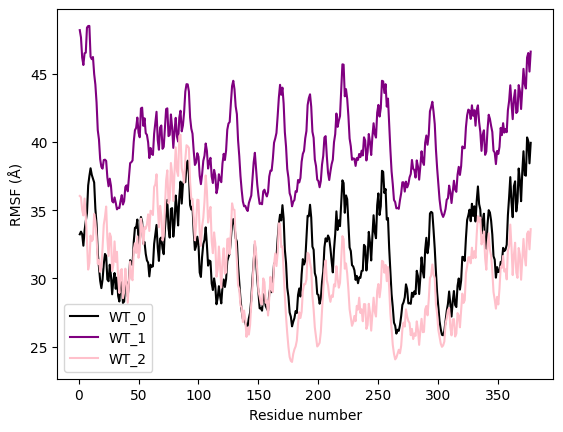

In [95]:
%matplotlib inline

# Plot RMSF of WT and other variants
plt.plot(c_alphas_WT_0_complete.resids,
         R_WT_0_complete.results.rmsf,
         color = 'black',
         label = 'WT_0'
         )
plt.plot(c_alphas_WT_1_complete.resids,
         R_WT_1_complete.results.rmsf,
         color = 'purple',
         label = 'WT_1'
         )
plt.plot(c_alphas_WT_2_complete.resids,
         R_WT_2_complete.results.rmsf,
         color = 'pink',
         label = 'WT_2'
         )

plt.xlabel('Residue number')
plt.ylabel('RMSF (Å)')

plt.legend()
plt.show()

First, the RMSF of all three predicted trajectories of the wildtype is compared. The plot shows that the three different trajectories differ quite a bit in RMSF, however the general patterns and thus the peaks and throughs seem to be quite similar. Albeit at a different amplitudes, suggesting that while the flexible and rigid regions are conserved, the extent of mobility in residues varies between the three trajectories. In order to compare this RMSF to that of mutant variants, I will first average the three RMSFs for WT. Instead of using the whole trajectory, I will switch to only using the final 50ns, because it will reduce the RMSF as it will not include the 'unfolding' of the protein at the start of the simulation (which is not necessarily part of how the protein moves under normal circumstances).

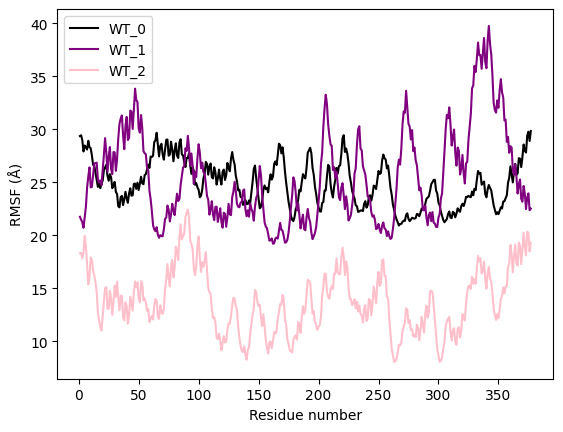

In [96]:
%matplotlib inline

# Plot RMSF of WT and other variants
plt.plot(c_alphas_WT_0.resids,
         R_WT_0.results.rmsf,
         color = 'black',
         label = 'WT_0'
         )
plt.plot(c_alphas_WT_1.resids,
         R_WT_1.results.rmsf,
         color = 'purple',
         label = 'WT_1'
         )
plt.plot(c_alphas_WT_2.resids,
         R_WT_2.results.rmsf,
         color = 'pink',
         label = 'WT_2'
         )

plt.xlabel('Residue number')
plt.ylabel('RMSF (Å)')

plt.legend()
plt.show()

As expected, the RMSF went down by quite a bit for all three trajectories, indicating that a lot of the mobility of the residues was caused by the unfolding of the protein from crystallized structure, to free protein in solvent. Notably, the peaks and throughs also seem less similar than when comparing the RMSF for the complete trajectories. This could indicate that the unfolding of the protein happened in a very similar manner for all three structures, and the noise was so large that it was those peaks and throughs that were noticed easily. WT_2 seems to have a lot lower RMSF than WT_1 and WT_0. WT_0 and WT_1 seem similar for the first 250 residues, after which the RMSF of WT_1 increases significantly. It is hard to say what trajectory would best predict real life HDAC8 dynamics, so I have decided to calculate an average using the three different RMSFs.

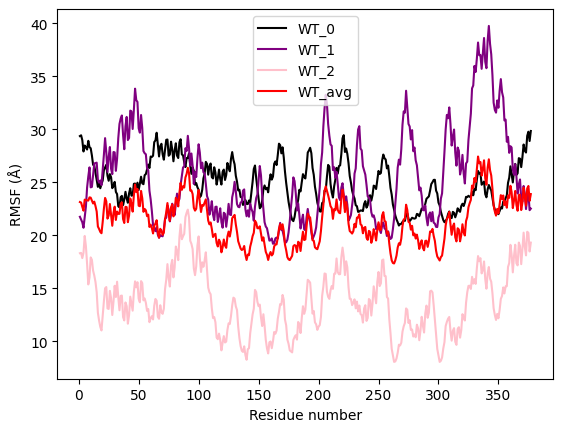

In [97]:
# Add all rmsf results together and divide by 3
avg_rmsf_WT = (R_WT_0.results.rmsf + R_WT_1.results.rmsf + R_WT_2.results.rmsf) / 3.0

# Plot RMSF of WT and other variants
plt.plot(c_alphas_WT_0.resids,
         R_WT_0.results.rmsf,
         color = 'black',
         label = 'WT_0'
         )
plt.plot(c_alphas_WT_1.resids,
         R_WT_1.results.rmsf,
         color = 'purple',
         label = 'WT_1'
         )
plt.plot(c_alphas_WT_2.resids,
         R_WT_2.results.rmsf,
         color = 'pink',
         label = 'WT_2'
         )

plt.plot(c_alphas_WT_0.resids,
         avg_rmsf_WT,
         color = 'red',
         label = 'WT_avg'
         )

plt.xlabel('Residue number')
plt.ylabel('RMSF (Å)')

plt.legend()
plt.show()


Above the average RMSF is shown in red, nicely located in the center of all three trajectories. This average RMSF will be used to compare to other variants. For the other variants I will also be using the average RMSF, based on the three trajectories for each variant.

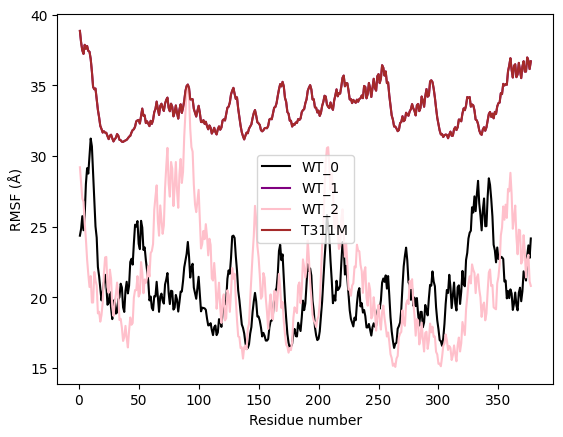

In [101]:
plt.plot(c_alphas_T311M_0.resids,
         R_T311M_0.results.rmsf,
         color = 'black',
         label = 'WT_0'
         )
plt.plot(c_alphas_T311M_1.resids,
         R_T311M_1.results.rmsf,
         color = 'purple',
         label = 'WT_1'
         )
plt.plot(c_alphas_T311M_2.resids,
         R_T311M_2.results.rmsf,
         color = 'pink',
         label = 'WT_2'
         )


plt.xlabel('Residue number')
plt.ylabel('RMSF (Å)')

plt.legend()
plt.show()

In [90]:
avg_rmsf_G320R = (R_G320R_0.results.rmsf + R_G320R_1.results.rmsf + R_G320R_2.results.rmsf) / 3.0
avg_rmsf_H334R = (R_H334R_0.results.rmsf + R_H334R_1.results.rmsf + R_H334R_2.results.rmsf) / 3.0
avg_rmsf_T311M = (R_T311M_0.results.rmsf + R_T311M_1.results.rmsf + R_T311M_2.results.rmsf) / 3.0
avg_rmsf_H180R = (R_H180R_0.results.rmsf + R_H180R_1.results.rmsf + R_H180R_2.results.rmsf) / 3.0

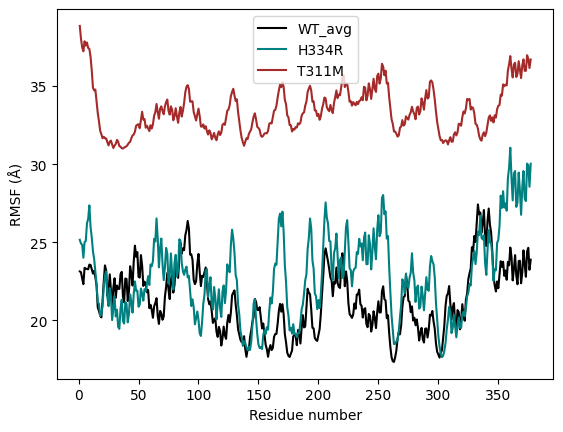

In [98]:
# Colors for annotating with secondary structure
colors = {
    'H': 'pink',      # helix
    'E': 'purple',     # sheet
    '-': 'lightgray' # loop
}

# Plot RMSF of WT and other variants
plt.plot(c_alphas_WT_0.resids,
         avg_rmsf_WT,
         color = 'black',
         label = 'WT_avg'
         )

plt.plot(c_alphas_H334R_0.resids,
         avg_rmsf_H334R,
         color = 'teal',
         label = 'H334R'
         )
plt.plot(c_alphas_T311M_0.resids,
         avg_rmsf_T311M,
         color = 'brown',
         label = 'T311M'
         )
plt.xlabel('Residue number')
plt.ylabel('RMSF (Å)')

#for i, ss in enumerate(secondary_structures[WT_0_secondary]):
 #   plt.axvspan(i, i+1, color=colors[ss], alpha=0.15, zorder=0)

plt.legend()
plt.show()

The RMSF of

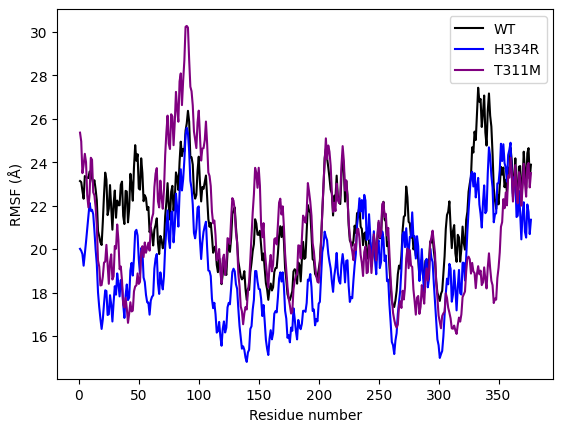

In [99]:
# Plot RMSF of WT and other variants
plt.plot(c_alphas_WT_0.resids,
         avg_rmsf_WT,
         color = 'black',
         label = 'WT'
         )
plt.plot(c_alphas_G320R_0.resids,
         avg_rmsf_G320R,
         color = 'blue',
         label = 'H334R'
         )
plt.plot(c_alphas_H180R_0.resids,
         avg_rmsf_H180R,
         color = 'purple',
         label = 'T311M'
         )
plt.xlabel('Residue number')
plt.ylabel('RMSF (Å)')
plt.legend()

#for i, ss in enumerate(secondary_structures[WT_secondary_0]):
 #   plt.axvspan(i, i+1, color=colors[ss], alpha=0.15, zorder=0)


Visibly, G320R and H334R have a lot lower RMSF than the wildtype.

### Distance Analysis

In [155]:
# Calculate dist from mutation to active site (Zn2+)
def dist_from_active_site(mutant, resid):
    zn = mutant.select_atoms("resid 378 and name ZN")
    site = mutant.select_atoms(resid)

    com1 = zn.center_of_mass()
    com2 = site.center_of_mass()
    dist = np.linalg.norm(com1-com2)

    return dist

mutant_dict = \
    { G320R_avg: ("G320R", "resid 320"),
      H180R_avg: ("H180R", "resid 180"),
      H334R_avg: ("H334R", "resid 334"),
      T311M_avg: ("T311M", "resid 311"),
      }

for mutant, (name, resid) in mutant_dict.items():
    dist = dist_from_active_site(mutant, resid)
    print(f"Distance from mutation {name} to active site: {round(dist, 2)}Å")


Distance from mutation G320R to active site: 22.59Å
Distance from mutation H180R to active site: 5.8Å
Distance from mutation H334R to active site: 30.7Å
Distance from mutation T311M to active site: 10.5Å


Mutation H180R seems to be the closest to the active site, with 5.8Å and H334R seems to be the mutation furthest away (30.7Å). It is possible that the distances to the active site play a role in how severe catalytic activity is affected.

In [2]:
# Calculate dist between any resid and Zn2+ ion, based on center of mass
def calculate_dist(universe, resid):
  cofactor = universe.select_atoms("resid 378 and name ZN")
  residue = universe.select_atoms(resid)

  dL = []
  for _ in universe.trajectory:
    com1 = cofactor.center_of_mass()
    com2 = residue.center_of_mass()
    dL.append(np.linalg.norm(com1-com2))

  return dL

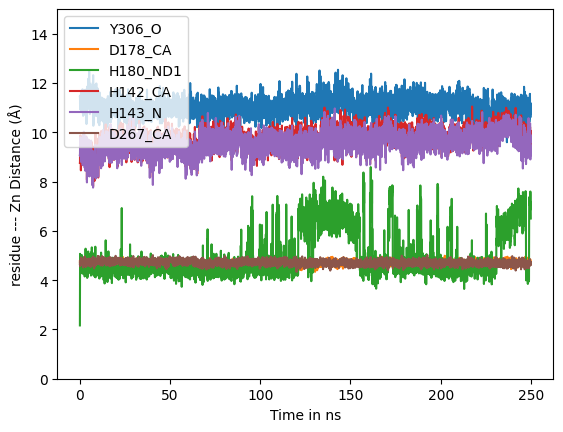

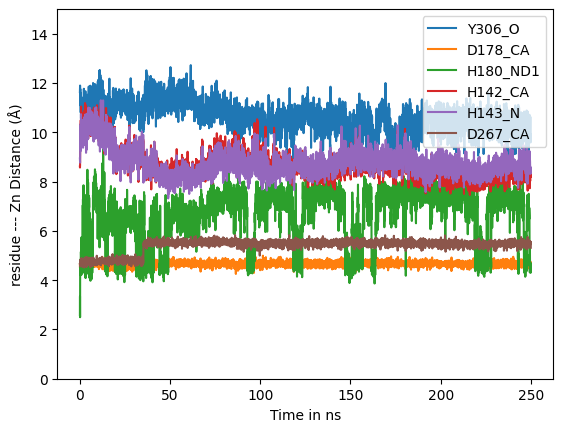

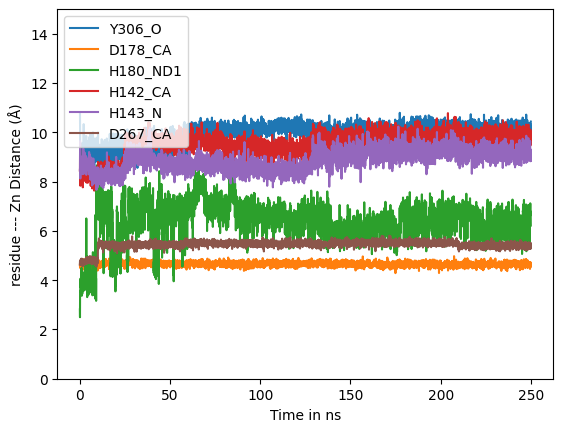

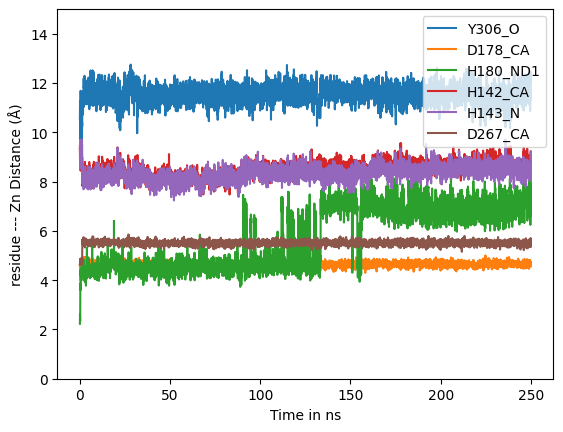

In [160]:
# Calculate dist between active site Zn2+ and vital residues for catalytic activity
def residue_zn_dist(variant):
    dL_variant_Y306 = calculate_dist(variant, "resid 306 and name O")
    dL_variant_D178 = calculate_dist(variant, "resid 178 and name CA")
    dL_variant_H180 = calculate_dist(variant, "resid 180 and name ND1")
    dL_variant_H142 = calculate_dist(variant, "resid 142 and name CA")
    dL_variant_H143 = calculate_dist(variant, "resid 143 and name N")
    dL_variant_D267 = calculate_dist(variant, "resid 267 and name CA")

    x = np.linspace(0, 250, len(dL_variant_Y306))

    plt.plot(x, dL_variant_Y306, label = "Y306_O")
    plt.plot(x, dL_variant_D178, label = "D178_CA")
    plt.plot(x, dL_variant_H180, label = "H180_ND1")
    plt.plot(x, dL_variant_H142, label = "H142_CA")
    plt.plot(x, dL_variant_H143, label = "H143_N")
    plt.plot(x, dL_variant_D267, label = "D267_CA")

    plt.ylabel("residue --- Zn Distance (Å)")
    plt.xlabel("Time in ns")
    plt.ylim(bottom=0, top=15)
    plt.legend()
    plt.show()

for variant in [WT, G320R, H334R, T311M]:
    residue_zn_dist(variant)

H180R has to be done seperately as there is no ND1

In [3]:
dL_H180R_Y306 = calculate_dist(variant, "resid 306 and name O")
dL_H180R_D178 = calculate_dist(variant, "resid 178 and name CA")
dL_H180R_H142 = calculate_dist(variant, "resid 142 and name CA")
dL_H180R_H143 = calculate_dist(variant, "resid 143 and name N")
dL_H180R_D267 = calculate_dist(variant, "resid 267 and name CA")

x = np.linspace(0, 250, len(dL_H180R_Y306))

plt.plot(x, dL_H180R_Y306, label = "Y306_O")
plt.plot(x, dL_H180R_D178, label = "D178_CA")
plt.plot(x, dL_H180R_H142, label = "H142_CA", color = "red")
plt.plot(x, dL_H180R_H143, label = "H143_N")
plt.plot(x, dL_H180R_D267, label = "D267_CA")

plt.ylabel("residue --- Zn Distance (Å)")
plt.xlabel("Time in ns")
plt.ylim(bottom=0)
plt.legend()
plt.show()

NameError: name 'variant' is not defined

https://userguide.mdanalysis.org/stable/examples/analysis/distances_and_contacts/distances_between_selections.html

The catalytic machinery lies at the end of the hydrophobic tunnel. The centerpiece of this region is a zinc ion that is bound to carboxylate oxygens of D178 and D267, and to the Nδ1 atom of H180

https://www.cell.com/structure/fulltext/S0969-2126(04)00159-5?_returnURL=https%3A%2F%2Flinkinghub.elsevier.com%2Fretrieve%2Fpii%2FS0969212604001595%3Fshowall%3Dtrue info over structuren

The simulations are 5000 frames of 0.5ns each (total 250ns). We want to only look at the final 50ns, as the protein will have folded out from crystallized structure. To do that we can use the code below. -b and -e are the start and endpoint measured in picoseconds.

```
gmx trjconv -f .xtc -o final_50ns.xtc -b 200000 -e 250000
```

Make subset version of tpr (no solvent) met echo 0
```
gmx convert-tpr -s ../../G320R-1/G320R-1-MD.tpr -n ../../index.ndx -o G320R-1-ion.tpr
```

Now the average configuration can be determined for each residue

```
gmx rmsf -f spliced.xtc -s G320R-1-ion.tpr -ox avg_structure.pdb
```



Text(0, 0.5, 'Distance (Å)')

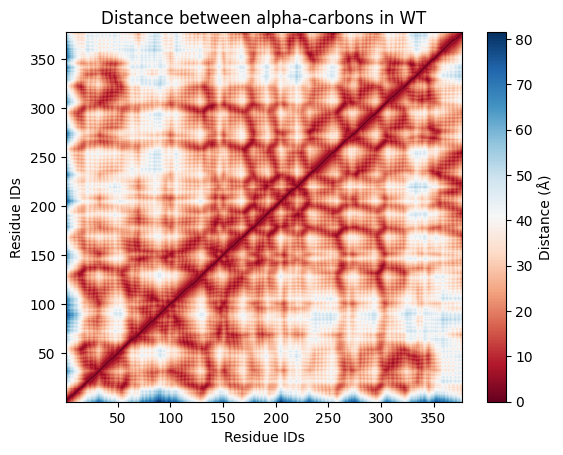

In [161]:
ca1 = WT_avg.select_atoms('name CA')
n_ca1 = len(ca1)

self_distances = distances.self_distance_array(ca.positions)
sq_dist_arr = np.zeros((n_ca1, n_ca1))
triu = np.triu_indices_from(sq_dist_arr, k=1)
sq_dist_arr[triu] = self_distances
sq_dist_arr.T[triu] = self_distances

fig, ax = plt.subplots()
im = ax.pcolor(ca1.resids, ca1.resids, sq_dist_arr)

# add figure labels and titles
plt.set_cmap("RdBu")
plt.ylabel('Residue IDs')
plt.xlabel('Residue IDs')
plt.title('Distance between alpha-carbons in WT')

# colorbar
cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Distance (Å)')


Text(0, 0.5, 'Distance (Å)')

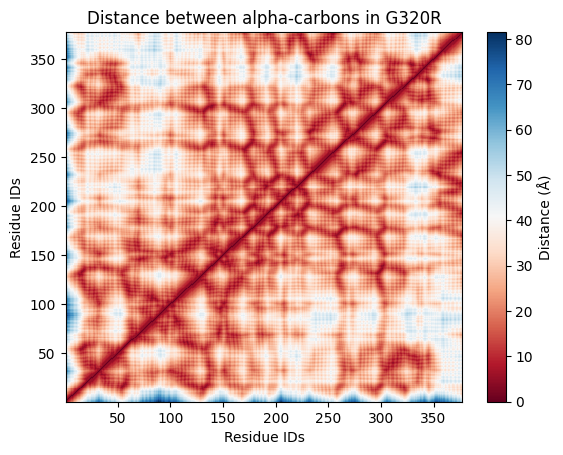

In [162]:
ca2 = G320R_avg.select_atoms('name CA')
n_ca2 = len(ca2)

self_distances = distances.self_distance_array(ca.positions)
sq_dist_arr = np.zeros((n_ca2, n_ca2))
triu = np.triu_indices_from(sq_dist_arr, k=1)
sq_dist_arr[triu] = self_distances
sq_dist_arr.T[triu] = self_distances

fig, ax = plt.subplots()
im = ax.pcolor(ca2.resids, ca2.resids, sq_dist_arr)

# add figure labels and titles
plt.set_cmap("RdBu")
plt.ylabel('Residue IDs')
plt.xlabel('Residue IDs')
plt.title('Distance between alpha-carbons in G320R')

# colorbar
cbar = fig.colorbar(im)
cbar.ax.set_ylabel('Distance (Å)')

The heatmaps above demonstrate the distances within the protein, between residues. The heatmaps are nice for observing things such as the secondary structures, e.g. the hexagonal patterns that display distance patterns of alpha helices. However, these heatmaps are not suited for comparing mutations to the WT, as the general structure of the proteins stays the same, having only a singular mutation. The differences in distance are not clearly noticeable in the heatmap and thus I will make heatmaps showing the delta difference between WT and mutation


is difficult to determine the difference in distance between alpha carbons between WT and G320R, as alpha carbons are more stabile and thus will likely not be that affected by a mutation. For this reason we will look at the delta distance between alpha carbons between the two variants.

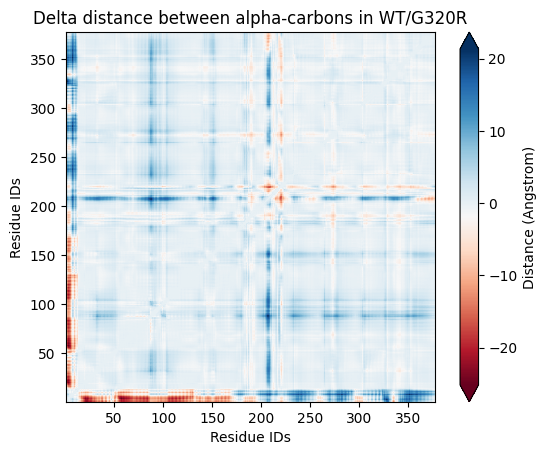

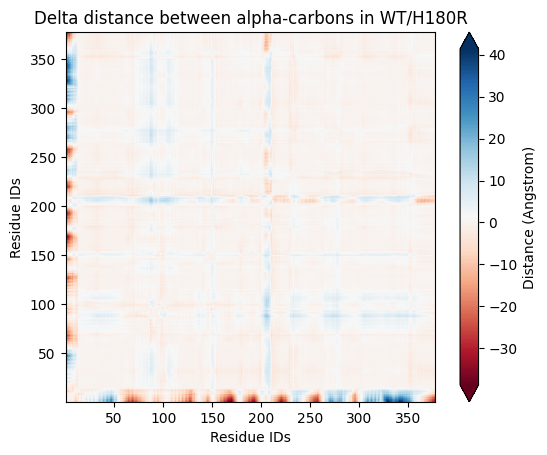

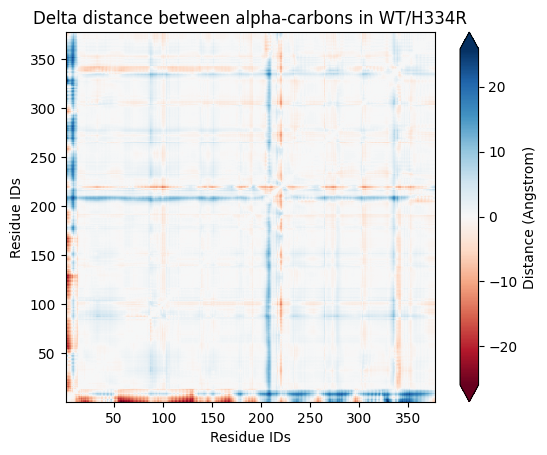

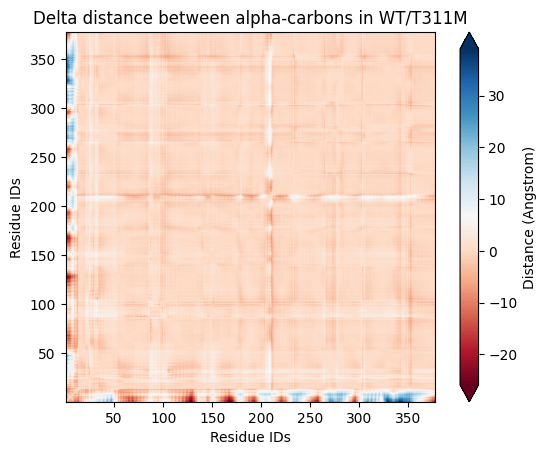

In [127]:
def delta_dist_WT_mutant(mutant, name):
    ca1 = WT_avg.select_atoms("name CA")
    ca2 = mutant.select_atoms("name CA")

    # pairwise distances
    distances_1 = distances.self_distance_array(ca1.positions)
    distances_2 = distances.self_distance_array(ca2.positions)

    N = len(ca1)
    M1 = np.zeros((N, N))
    M2 = np.zeros((N, N))

    triu = np.triu_indices(N, k=1)

    M1[triu] = distances_1
    M1.T[triu] = distances_1

    M2[triu] = distances_2
    M2.T[triu] = distances_2

    delta = M2 - M1  # Diff between coordinates of WT and mutant

    fig, ax = plt.subplots()
    im = ax.pcolor(ca1.resids, ca1.resids, delta)

    # Make heatmap square
    ax.set_aspect('equal')

    # add figure labels and titles
    plt.ylabel('Residue IDs')
    plt.xlabel('Residue IDs')
    plt.title(f'Delta distance between alpha-carbons in WT/{name}')
    plt.set_cmap("BuRd")

    # colorbar
    cbar = fig.colorbar(im, extend='both')
    cbar.ax.set_ylabel('Distance (Å)')
    plt.show()

mutant_dict = {G320R_avg:"G320R", H180R_avg:"H180R", H334R_avg:"H334R", T311M_avg:"T311M"}

for mutant in mutant_dict:
    delta_dist_WT_mutant(mutant, mutant_dict[mutant])


Looking at the four heatmaps above, the Δdifference in alpha-carbon position can be seen over the average configuration of the last 50ns of the simulation. The distance is measured in Ångström and a red color means that the alpha-carbons of two residues were closer together than in the WT. A blue color means the opposite, the alpha-carbons of two residues were further away from eachother compared to the WT.

#### WT/G320R
Most of the residues seem to be further away from eachother compared to the WT. Especially residue ~210 seems to have an increased distance of 10-20 Å with most other residues, leading to a distinct 'cross-shaped' line in the heatmap. There seems to be another `line` that has formed, around residue 90, all other residues seem to have moved 5-20 Å further away. The distinct cross shape could point towards there being more than one structural domain. According to literature and also the [UniProt entry for HDAC8](https://www.uniprot.org/uniprotkb/Q9BY41/entry#family_and_domains), the protein only has one defined domain, from residue 14 to 324. But what the heatmap shows looks like there are 2 or more separate domains in this mutation.

Around the lower part there seems to be quite some noise, residue ~1-15 seems to have moved closer to the first ~160 residues and further away from the residues that follow after. This could be explained by pure coincidence, as this is a loop at the very start of the protein and it likely moves a lot as it does not have a set structure. Residue 1-14 were also not taken into account for further analysis in the PCA, to reduce noise.


#### WT/H180R
Similar shapes and patterns to WT/G320R can be found in this heapmap. The cross shape is again visible, however this time a lot lighter in color, indicating the different domains theory is perhaps less applicable for this mutation. In general the rest of the heatmap also seems lighter in color compared to G320R, meaning that the positions of alpha carbons seems less affected by the H180R mutation. This is unexpected, as both H180R and G320R have little to no remaining catalytic activity, so it would be expected that both differ quite a bit in structure to the WT. A hypothesis could be that the mutation of residue 180, which lies in the active site, only led to local changes, which results in a protein with a nearly identical structure to WT, but without catalytic activity.

#### WT/H334R
2 distinct lines seem visible, the line causing the cross shape as seen in the other mutations and a secondary cross shape that becomes visible as a result of residue ~220 moving closer to all other residues. None of the other mutations had this very clear double cross shape, where one is further away and the one next to it is closer. This could indicate some sort of 'pulling' motion, that where residue ~210 moves further away, residue ~220 moves closer. H334R has almost full remaining catalytic activity (91%) which is noteworthy, as the Δdistances of alpha carbons seems to differ quite a bit to the WT, even in a part of the active site (which mostly takes place between ~140 and ~306).


#### WT/T311M
It is very clear that within the histone deacetylase domain (almost) every residue is closer to (almost) all other residues, compared to WT. This is quite interesting, as this means the entire protein became more compact as a result of the mutation. The same two distinct cross shaped lines as in G320R can be seen in this mutation too.

#### Conclusion:
Mutations along the sequence of HDAC8 seem to have an effect on the distance between residues, resulting in a change in coordination all together. Across the different mutations certain patterns can be found, such as the intricate cross shaped lines caused by a singular residue that has shifted further or closer to (almost) all other residues.

The loop sequence at the start of the protein (res 1-14) seems to cause noise with no noticeable pattern and should be excluded from further analysis.

## PCA
PCA (Principal Component Analysis) was performed on each of the variants, one PCA including all atoms and one including only key components to the catalytic activity of HDAC8. Both PCA's were done on 3 different simulations at once, meaning 3 different structures as predicted by AlphaFold and their corresponding trajectories as simulated by GROMACS. This was done to be able to provide more certainty that certain movements that were observed in the proteins are not purely caused by chance.


### PCA of entire protein
For the PCA of the entire protein the script below was used. 0, 1 and 2 stand for the different structures/trajectories. The input structures are all generated using the SnakeMake pipeline on the GROMACS output data. Hydrogen atoms were removed as they move a lot which can result in noise in the PCA. The structures are fitted twice, first they are fitted internally using `intra_fit` and next all three are fitted onto each other, using `extra_fit`. Fitting was only done on alpha carbons (ca), also known as the backbone of the protein. Residues 1-15 were excluded, as they added a lot of noise, as it was a loop structure at the very beginning of the protein. When fitting the structures onto each other, all secondary structure loops were excluded, as they move a lot. The results of the fitting will have a smaller RMSD when only fitted on more stable structures, including the alpha helixes and beta sheets.

PCA was performed on the final 1000 frames of the simulation, which is a total of 50ns. The first part of the simulation mostly consists of the protein unfolding from crystallized state, to its true state in a solvent. For performing the PCA `princomp.py` was used, a script made by my lecturer Tsjerk Wassenaar.

```
load WT-0-ion.pdb, WT-0
load WT-0-ion.xtc, WT-0

load WT-1-ion.pdb, WT-1
load WT-1-ion.xtc, WT-1

load WT-2-ion.pdb, WT-2
load WT-2-ion.xtc, WT-2

remove hydro

intra_fit WT-0 and n. ca and not i. 1-14
intra_fit WT-1 and n. ca and not i. 1-14
intra_fit WT-2 and n. ca and not i. 1-14

# align the three different simulations
extra_fit not ss L

run princomp.py

# only perform PCA on final 1000 frames (= final 50 ns)
P=Princomp("not i. 1-15", frames=slice(4002,-1))

# boxplot
P[1].box(radii=(0.05, 0.2, 0.15, 0.2, 0.05)).draw("pc1box")
P[2].box(radii=(0.05, 0.2, 0.15, 0.2, 0.05)).draw("pc2box")

# violin plot
P[1].violin().draw("pc1violin")
P[2].violin().draw("pc2violin")

P[1].violin().recolor(x=P[1].scores, y=P.data.states).draw("pc1time")
P[2].violin().recolor(x=P[2].scores, y=P.data.states).draw("pc2time")

P.drawmean()
show cartoon, pcmean
hide lines
spectrum resi, grey30_grey90, pcmean
set cartoon_fancy_helices,
show spheres, pcmean and ele zn
```

### PCA of catalytic site

As the core components of the catalytic site are all embedded or enclosed in a cave-like structure, likely they do not have the space or capacity to be highly mobile, so to be able to notice minor differences in movement the noise of all other atoms of the protein was removed.

Below is the preprocessing that was also used to generate the image at the chapter discussing the structure.

```
load WT-0-ion.pdb, WT-0
load WT-0-ion.xtc, WT-0

load WT-1-ion.pdb, WT-1
load WT-1-ion.xtc, WT-1

load WT-2-ion.pdb, WT-2
load WT-2-ion.xtc, WT-2

remove hydro

intra_fit WT-0 and n. ca and not i. 1-14
intra_fit WT-1 and n. ca and not i. 1-14
intra_fit WT-2 and n. ca and not i. 1-14

# align the three different simulations
extra_fit not ss L

# select all core components
sele active_region, resi 142+143+151+152+176+178+180+183+208+267+274+306
label i. 306 and n. OH, resn + resi
label i. 267 and n. OD2, resn + resi
label i. 180 and n. ND1, resn + resi
label i. 143 and n. NE2, resn + resi
label i. 178 and n. OD1, resn + resi
label i. 274 and n. CE, resn + resi
label i. 152 and n. CE2, resn + resi
label i. 151 and n. CA, resn + resi
label i. 208 and n. CE1, resn + resi

set cartoon_fancy_helices,

```

Now we can continue with the PCA:

```
run princomp.py

# only perform PCA on final 1000 frames (= final 50 ns)
P=Princomp("not i. 1-14", frames=slice(4002,-1))

# boxplot
P[1].box(radii=(0.05, 0.2, 0.15, 0.2, 0.05)).draw("pc1box")
P[2].box(radii=(0.05, 0.2, 0.15, 0.2, 0.05)).draw("pc2box")

# violin plot
P[1].violin().draw("pc1violin")
P[2].violin().draw("pc2violin")

P[1].violin().recolor(x=P[1].scores, y=P.data.states).draw("pc1time")
P[2].violin().recolor(x=P[2].scores, y=P.data.states).draw("pc2time")

P.drawmean()
show cartoon, pcmean
hide lines
spectrum resi, grey30_grey90, pcmean
set cartoon_fancy_helices,
show spheres, pcmean and ele zn
```

### Analysis of PCA

For analysis I focused on the first two components (PC1/PC2), as they describe the majority of movements that take place.

#### WT

|           | RMSD               |
|-----------|--------------------|
| WT-0/WT-1 | 0.997 (2060 atoms) |
| WT-0/WT-2 | 0.876 (2186 atoms) |

##### Entire protein
**PC1**

![](imgs/WT_PCA1.png)
![](imgs/WT_PCA1_2.png)




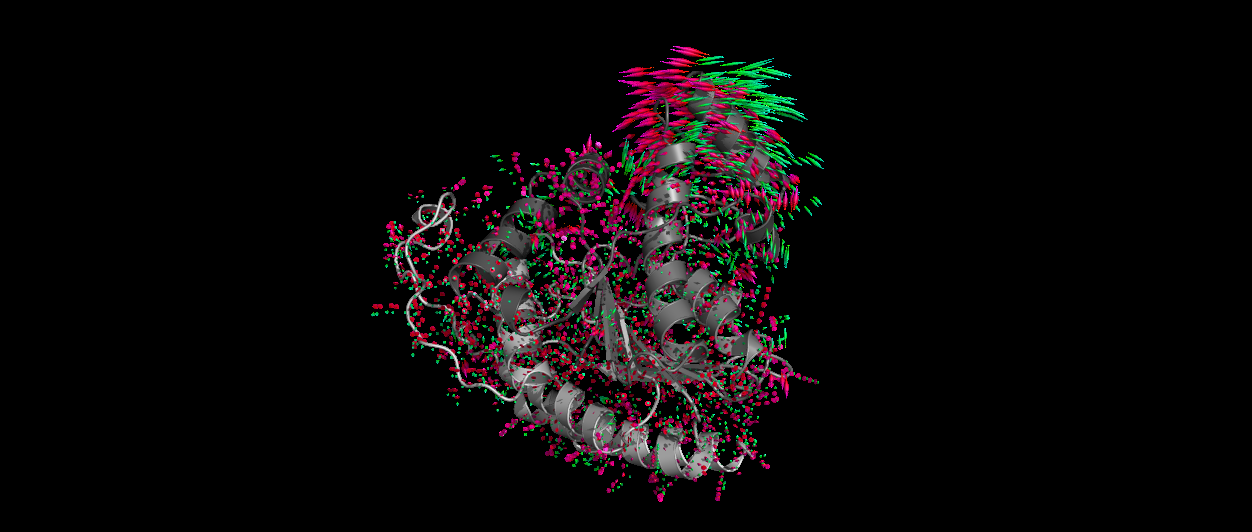

From the images above, a clear rotating movement can be seen from two different angles. Taking place in an alpha helix and surrounding loops (~ res 64-114). This rotating movement seems to be able to bring the helix inwards, towards the active site and also move away from it again.

**PC2**
![](imgs/WT_PCA2_2.png)



![](imgs/WT_PCA2.png)

From PC2, various movements can be seen. The same movement as PC1 is again shown in PC2, however this time the violin plots are perpendicular to those of PC1, signifying the actual direction of the movement. 2 other visible movements take place in loops, where they have a very distinct linear movement with little to no curve. The loops move inward/outward from the active site.

![](imgs/WT_PCA2_3.png)


For the movement over time, blue and red signify start/endpoints. A constant change between configurations can be seen as a violet color. Most violin plots have a purple middle region, signifying that the protein can easily shift within these middle boundaries. At the ends of the violin plots, a (light) red color can be seen, signifying that the protein stops changing configurations once it reaches this point, or at least remain in this same configuration for an extended period of time.

![](imgs/WT_PCA2_time.png)




##### Active site


#### G320R

The three simulations were fitted onto eachother according to the preprocessing steps in the PyMol script above, resulting in:

|                | RMSD               |
|----------------|--------------------|
| G320R-0/G320R-1| 0.965 (2241 atoms) |
| G320R-0/G320R-2| 1.000 (2162 atoms) |

##### Entire protein
**PC1**

![](imgs/G320R_PCA1.png)




Most of the movement of PC1 seems to take place in the structures above the active site. On the left the moving structure consists of a loop (res 204-212) and on the right it consists of a loop and an alpha helix (75-101). The movement shows some kind of in/out configuration where both structures move either inwards towards the active site or outwards, away from the active site. Other than these two movements no other significant movements can be seen in PC1.

![](imgs/G320R_PCA1_time.png)

Above, the movements are coloured over time, where blue/red are the end/startpoints. Almost all of the violinplots are coloured a distinct purple color, indicating that the protein seems to be continuously moving through conformations, rather than jumping between two fixed endpoints.

##### PC2

![](imgs/G320R_PCA2.png)

![](imgs/G320R_PCA2_2.png)

Most of the violin plots appear short, indicating that displacement was not that severe (likely because those movements were already captured in PC1). The movement patterns in general also seem smaller, as the violin plot no longer consists of 2 thick points at each end, connected by a very thin line in the middle. For the second component, many element movements involve 3 or 4 visible points where the configuration may be located.

One noticeable movement that can be seen, takes place around one of the alpha helices near the active site, including some surrounding loops (~res 64-114). The first image shows this movement from a side-view perspective, and the second image from a front facing perspective, with the active site centrally. It looks like a rotating motion that allows the helix to move closer to the active site and away from it, showing an "open"/"close" configuration. No other distinct movement patterns seem visible from the second component.

##### Active site
Below the first three components can be seen for G320R-0, G320R-1 and G320R-2. Most of the movements seem relatively small, but on the top left side there seems to be a very large movement happening (this can be seen from the length of the violin plot).
![](imgs/PCA_G320R_active_site.png)


#### Comparison to wildtype
The rotation movement of WT PC1 was seen in G320R PC2, signifying that the movement that WT PC1 describes has gotten smaller for mutation G320R or that other movements have become larger.

## Conclusion

## Reflection

Hereby I will reflect on this course and the resulting model. I have really enjoyed this course as it allowed me to further explore into the field of molecular dynamics. I noticed that I have gotten more familiar/comfortable in using PyMol, GROMACS and libraries such as MDAnalysis. However a challenging part for me was that when I delve into a topic, I like to learn all about it. That's when I found out how complex and extensive this field really is, I felt a bit overwhelmed but it made me really happy because this meant that every single day I learnt new things and every week I could look back at my progress and think 'wow I really learnt a lot this week, last week I didn't know about any of this!'. Next month I start my internship, and while my internship will not be related to molecular dynamics, I am looking forward to show the research that I was able to do to the people a the lab (as this project conveniently was strongly related to the research they do.

### Limitations
- As mentioned above, the field of molecular dynamics is very extensive. This project took approximately 3/4 weeks in total, and it was a bit challenging to consider the methods that can be applied to answer the research question. Methods and analysis I applied during this project include distance analysis, PCA (using PyMol), and RMSF/secondary structure analysis. If I had had extra time, I would have liked to look into more noteworthy structures of HDAC8. An example of this is the two loops as mentioned in ...(source). It could also have been interesting to look into the structure of HDAC8 with a phosphorylated Ser39 residue, as has been described in literature by Somoza et al. (2004). Simulations were run using this conformation, but sadly, a lack of time did not allow for further analysis.

- I felt that molecular dynamics data is a bit harder to interpret as opposed to workflows with e.g. genomics/transcriptomics, etc. I think the results I have can form a nice start for further research, but I am aware that at this point it is hard to make any definitive conclusions.

- Due to the limited project time, there was not much time to come up with a project proposal. I think if I had more time, I would have spent longer doing literature research into all discovered mutations so far and select the ones that have been least studied. For this project, I just selected all mutants as discussed in the article by Deardorff et al. (2012). A nice idea could have been to select mutants that display a gradient of remaining catalytic activity. Right now, all selected mutants have very low remaining catalytic activity, with 3 of them being (almost) 0% (T311M, G320R and H180R), and the fourth mutation having high remaining catalytic activity of 91% (H334R). It might have been better to study variants that range from no remaining activity, to some to quite a bit, to having almost full catalytic activity remaining.

I am satisfied with what cam of the final product and I am happy I got to learn so many new things about the MD field in such a short time. I also think HDAC8 was a very interesting protein to analyse. I think something that I can take into account for example during my internship, to make sure that I have realistic expectations is to really thoroughly work on a plan of approach, where I focus more on what exactly I want to reach in the time I have and what other things could be nice as additions.


# Sources
- Drazic, A., Myklebust, L. M., Ree, R., & Arnesen, T. (2016). The world of protein acetylation. Biochimica Et Biophysica Acta (BBA) - Proteins And Proteomics, 1864(10), 1372–1401. https://doi.org/10.1016/j.bbapap.2016.06.007
- De Ruijter, A. J., Van Gennip, A. H., Caron, H. N., Kemp, S., & Van Kuilenburg, A. B. (2003). Histone deacetylases (HDACs): characterization of the classical HDAC family. Biochemical Journal, 370(3), 737–749. https://doi.org/10.1042/bj20021321
- Deardorff, M. A., Bando, M., Nakato, R., Watrin, E., Itoh, T., Minamino, M., Saitoh, K., Komata, M., Katou, Y., Clark, D., Cole, K. E., De Baere, E., Decroos, C., Di Donato, N., Ernst, S., Francey, L. J., Gyftodimou, Y., Hirashima, K., Hullings, M., . . . Shirahige, K. (2012). HDAC8 mutations in Cornelia de Lange syndrome affect the cohesin acetylation cycle. Nature, 489(7415), 313–317. https://doi.org/10.1038/nature11316
- Bekker, Henk & Berendsen, Herman & Dijkstra, E.J. & Achterop, S. & Drunen, Rudi & van der Spoel, David & Sijbers, A. & Keegstra, H. & Reitsma, B. & Renardus, M.K.R.. (1993). Gromacs: A parallel computer for molecular dynamics simulations. Physics Computing. 92. 252-256.
- Brooks, B. R., Brooks, C. L., Mackerell, A. D., Nilsson, L., Petrella, R. J., Roux, B., Won, Y., Archontis, G., Bartels, C., Boresch, S., Caflisch, A., Caves, L., Cui, Q., Dinner, A. R., Feig, M., Fischer, S., Gao, J., Hodoscek, M., Im, W., . . . Karplus, M. (2009). CHARMM: The biomolecular simulation program. Journal Of Computational Chemistry, 30(10), 1545–1614. https://doi.org/10.1002/jcc.21287
- D.A. Case, H.M. Aktulga, K. Belfon, I.Y. Ben-Shalom, J.T. Berryman, S.R. Brozell, F.S. Carvahol, D.S. Cerutti, T.E. Cheatham, III, G.A. Cisneros, V.W.D. Cruzeiro, T.A. Darden, N. Forouzesh, M. Ghazimirsaeed, G. Giambaşu, T. Giese, M.K. Gilson, H. Gohlke, A.W. Goetz, J. Harris, Z. Huang, S. Izadi, S.A. Izmailov, K. Kasavajhala, M.C. Kaymak, I. Kolossv\'a ry, A. Kovalenko, T. Kurtzman, T.S. Lee, P. Li, Z. Li, C. Lin, J. Liu, T. Luchko, R. Luo, M. Machado, M. Manathunga, K.M. Merz, Y. Miao, O. Mikhailovskii, G. Monard, H. Nguyen, K.A. O'Hearn, A. Onufriev, F. Pan, S. Pantano, A. Rahnamoun, D.R. Roe, A. Roitberg, C. Sagui, S. Schott-Verdugo, A. Shajan, J. Shen, C.L. Simmerling, N.R. Skrynnikov, J. Smith, J. Swails, R.C. Walker, J. Wang, J. Wang, X. Wu, Y. Wu, Y. Xiong, Y. Xue, D.M. York, C. Zhao, Q. Zhu, and P.A. Kollman (2025), Amber 2025, University of California, San Francisco.
- De Lange, C. (1933). Surun type nouveau degeneration (typus Amestelodamensis). Arch Med Enfants, 36, 713-719.
- Kline, A. D., Moss, J. F., Selicorni, A., Bisgaard, A., Deardorff, M. A., Gillett, P. M., Ishman, S. L., Kerr, L. M., Levin, A. V., Mulder, P. A., Ramos, F. J., Wierzba, J., Ajmone, P. F., Axtell, D., Blagowidow, N., Cereda, A., Costantino, A., Cormier-Daire, V., FitzPatrick, D., . . . Hennekam, R. C. (2018). Diagnosis and management of Cornelia de Lange syndrome: first international consensus statement. Nature Reviews Genetics, 19(10), 649–666. https://doi.org/10.1038/s41576-018-0031-0
- Deardorff, M. A., Porter, N. J., & Christianson, D. W. (2016). Structural aspects of HDAC8 mechanism and dysfunction in Cornelia de Lange syndrome spectrum disorders. Protein Science, 25(11), 1965–1976. https://doi.org/10.1002/pro.3030
- Osko, J. D., Porter, N. J., Decroos, C., Lee, M. S., Watson, P. R., Raible, S. E., Krantz, I. D., Deardorff, M. A., & Christianson, D. W. (2020). Structural analysis of histone deacetylase 8 mutants associated with Cornelia de Lange Syndrome spectrum disorders. Journal Of Structural Biology, 213(1), 107681. https://doi.org/10.1016/j.jsb.2020.107681
- Decroos, C., Christianson, N. H., Gullett, L. E., Bowman, C. M., Christianson, K. E., Deardorff, M. A., & Christianson, D. W. (2015). Biochemical and Structural Characterization of HDAC8 Mutants Associated with Cornelia de Lange Syndrome Spectrum Disorders. Biochemistry, 54(42), 6501–6513. https://doi.org/10.1021/acs.biochem.5b00881
- Somoza, J. R., Skene, R. J., Katz, B. A., Mol, C., Ho, J. D., Jennings, A. J., Luong, C., Arvai, A., Buggy, J. J., Chi, E., Tang, J., Sang, B., Verner, E., Wynands, R., Leahy, E. M., Dougan, D. R., Snell, G., Navre, M., Knuth, M. W., . . . Tari, L. W. (2004). Structural Snapshots of Human HDAC8 Provide Insights into the Class I Histone Deacetylases. Structure, 12(7), 1325–1334. https://doi.org/10.1016/j.str.2004.04.012
- Vannini, A., Volpari, C., Filocamo, G., Casavola, E. C., Brunetti, M., Renzoni, D., Chakravarty, P., Paolini, C., De Francesco, R., Gallinari, P., Steinkühler, C., & Di Marco, S. (2004). Crystal structure of a eukaryotic zinc-dependent histone deacetylase, human HDAC8, complexed with a hydroxamic acid inhibitor. Proceedings Of The National Academy Of Sciences, 101(42), 15064–15069. https://doi.org/10.1073/pnas.0404603101
- Finnin, M. S., Donigian, J. R., Cohen, A., Richon, V. M., Rifkind, R. A., Marks, P. A., Breslow, R., & Pavletich, N. P. (1999). Structures of a histone deacetylase homologue bound to the TSA and SAHA inhibitors. Nature, 401(6749), 188–193. https://doi.org/10.1038/43710
- Decroos, C., Christianson, N. H., Gullett, L. E., Bowman, C. M., Christianson, K. E., Deardorff, M. A., & Christianson, D. W. (2015b). Biochemical and Structural Characterization of HDAC8 Mutants Associated with Cornelia de Lange Syndrome Spectrum Disorders. Biochemistry, 54(42), 6501–6513. https://doi.org/10.1021/acs.biochem.5b00881
- Decroos, C., Bowman, C. M., Moser, J. S., Christianson, K. E., Deardorff, M. A., & Christianson, D. W. (2014). Compromised Structure and Function of HDAC8 Mutants Identified in Cornelia de Lange Syndrome Spectrum Disorders. ACS Chemical Biology, 9(9), 2157–2164. https://doi.org/10.1021/cb5003762